# IPL Data Analysis (2008 - 2024)

**Author:** Yashkumar Sharma | B.E. Computer Engineering Graduate | Pursuing M.Tech in Operations Research

Cricket is more than a sport in India — it's a religion. The Indian Premier League (IPL) 
since its inception in 2008 has been a goldmine of data. In this notebook, I've tried to 
go beyond the scorecard and dig into what the numbers actually say about teams, players, 
venues and match outcomes over 16 seasons.

**Objective:** Uncover patterns and insights from IPL match and delivery level data  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** IPL Complete Dataset — Kaggle

## Importing Libraries

Starting with the usual suspects — Pandas and NumPy for data manipulation, 
Matplotlib and Seaborn for visualization.

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully ✅")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


Libraries imported successfully ✅
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/matches.csv
/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/deliveries.csv


## Loading the Dataset

Two datasets are used throughout this analysis —
- **matches.csv** — match level data covering 1095 IPL matches
- **deliveries.csv** — ball by ball data covering 260,920 deliveries

In [14]:
matches = pd.read_csv('/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/matches.csv')
deliveries = pd.read_csv('/kaggle/input/datasets/patrickb1912/ipl-complete-dataset-20082020/deliveries.csv')

print("matches shape:", matches.shape)
print("deliveries shape:", deliveries.shape)

matches shape: (1095, 20)
deliveries shape: (260920, 17)


## Data Overview

Before jumping into analysis, it's important to understand the structure of both datasets — 
column names, data types, and where the missing values are hiding.

In [15]:
print("=== MATCHES DATASET ===")
print(matches.head())
print("\nShape:", matches.shape)
print("\nColumns:", matches.columns.tolist())
print("\nData Types:\n", matches.dtypes)
print("\nNull Values:\n", matches.isnull().sum())

=== MATCHES DATASET ===
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_dec

In [16]:
print("=== DELIVERIES DATASET ===")
print(deliveries.head())
print("\nShape:", deliveries.shape)
print("\nColumns:", deliveries.columns.tolist())
print("\nNull Values:\n", deliveries.isnull().sum())

=== DELIVERIES DATASET ===
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed

## Data Cleaning

A quick look at the null values revealed a few columns that needed attention. 
Most nulls were either expected (like DLS method applying only to rain affected matches) 
or could be safely filled. Rows with no match result were dropped since they don't 
contribute to win/loss analysis.

In [17]:
matches[matches['winner'].isnull()] #just checking why the 5 of them are null and can the dropping be prevented.

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [18]:
# filling Null values
matches['city'].fillna('Unknown', inplace=True) # this will fill the NULL values in city with Unknown
matches['result_margin'].fillna(0, inplace=True) # this will fill the NULL values in result_margin with 0
matches['target_runs'].fillna(0, inplace=True) # this will fill the NULL values in target_runs with 0
matches['target_overs'].fillna(0, inplace=True) # this will fill the NULL values in target_overs with 0

# dropping null values 
matches.dropna(subset=['winner'], inplace=True) # this will drop the null values in winner col

# Verify cleaning
print("Remaining nulls in matches:")
print(matches.isnull().sum())
print("\nMatches shape after cleaning:", matches.shape)

Remaining nulls in matches:
id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin         0
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64

Matches shape after cleaning: (1090, 20)


## Team Performance Analysis

Starting with the big picture — which teams have dominated the IPL across all seasons, 
how consistent have they been, and does winning the toss actually translate to winning matches?

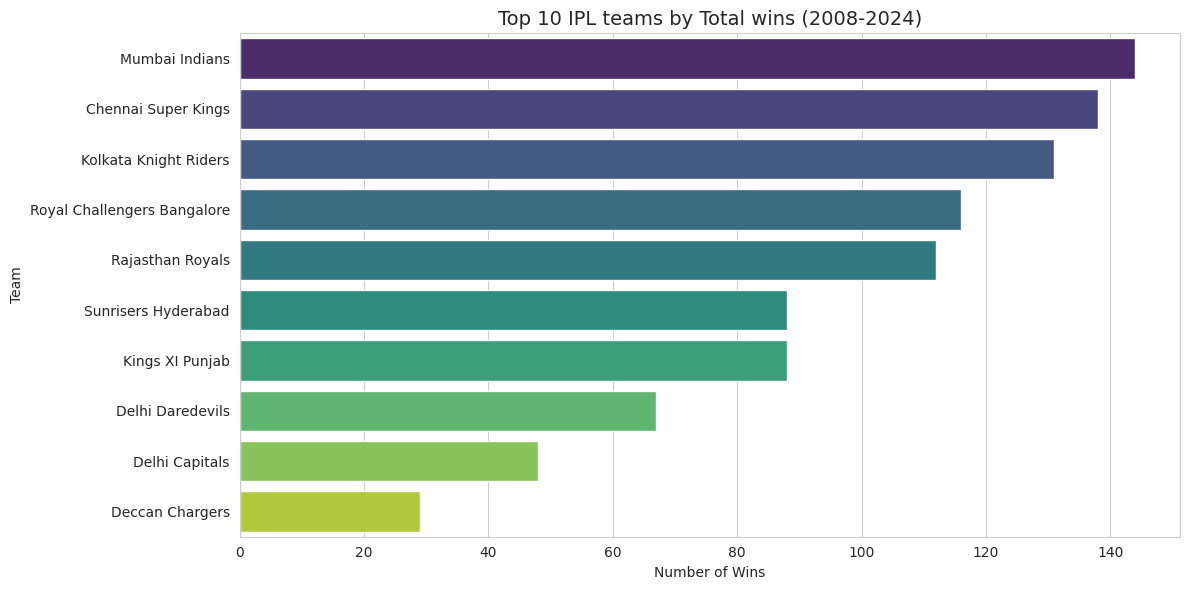

In [19]:
top_winners = matches['winner'].value_counts().head(10).reset_index()
top_winners.columns = ['team', 'wins']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_winners, x='wins', y='team', palette='viridis') # horizontal bar plot for better visual
plt.title('Top 10 IPL teams by Total wins (2008-2024)', fontsize=14)
plt.xlabel('Number of Wins')
plt.ylabel('Team')

plt.tight_layout()
plt.show()

**Insight:** Mumbai Indians lead the all-time wins chart with 145+ wins, 
followed closely by Chennai Super Kings. These two franchises have been the 
most consistent performers across all IPL seasons — a dominance that reflects 
strong team management and player retention strategies.

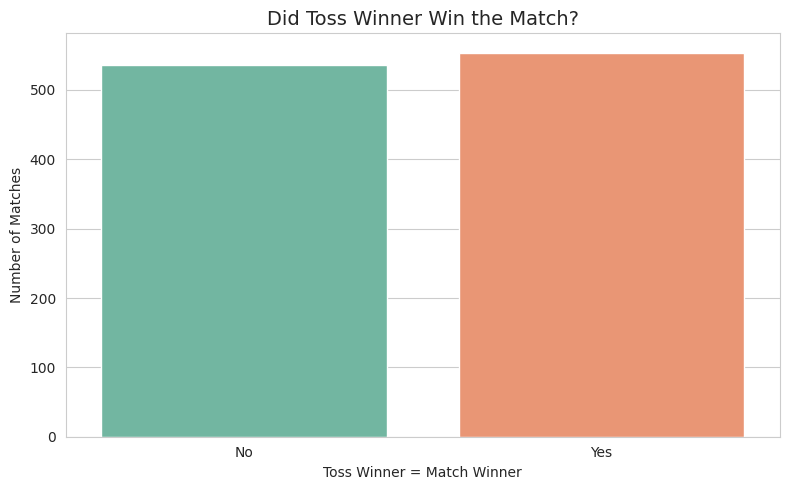

In [20]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts().reset_index()
toss_impact.columns = ['toss_won_match', 'count']

plt.figure(figsize=(8, 5))
sns.barplot(data=toss_impact, x='toss_won_match', y='count', palette='Set2')
plt.title('Did Toss Winner Win the Match?', fontsize=14)
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Number of Matches')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

**Insight:** Toss winning teams won approximately 550 matches vs 535 losses — 
a difference of barely 2-3%. This tells us that the toss has minimal impact on 
match outcomes in the IPL. Skill, team composition and execution on the day 
matter far more than the coin flip.

## Batting Analysis

Moving from teams to individual brilliance — who are the run machines of the IPL? 
Let's look at the top run scorers, highest strike rates and the best batting 
performances across all seasons.

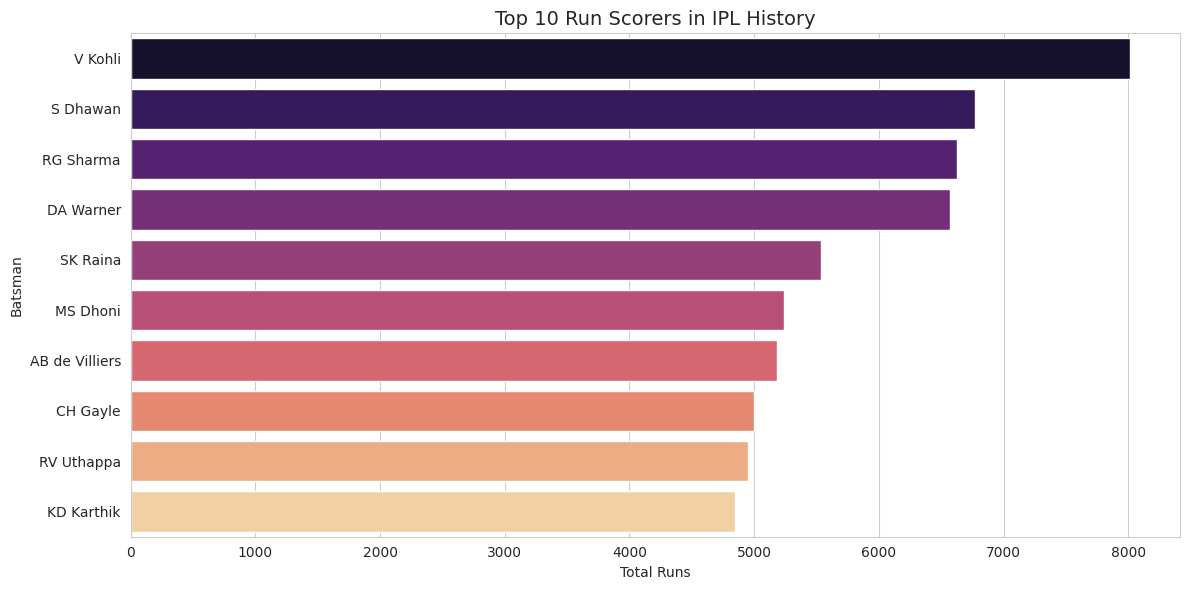

In [21]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).reset_index()
top_batsmen.columns = ['batter', 'runs']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_batsmen, x='runs', y='batter', palette='magma')
plt.title('Top 10 Run Scorers in IPL History', fontsize=14)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

**Insight:** Virat Kohli stands alone at the top with 8000+ runs — nearly 1500 runs 
ahead of Shikhar Dhawan in second place. The top 4 (Kohli, Dhawan, Rohit, Warner) 
are all openers, highlighting how crucial the powerplay and opening partnerships 
are in T20 cricket.

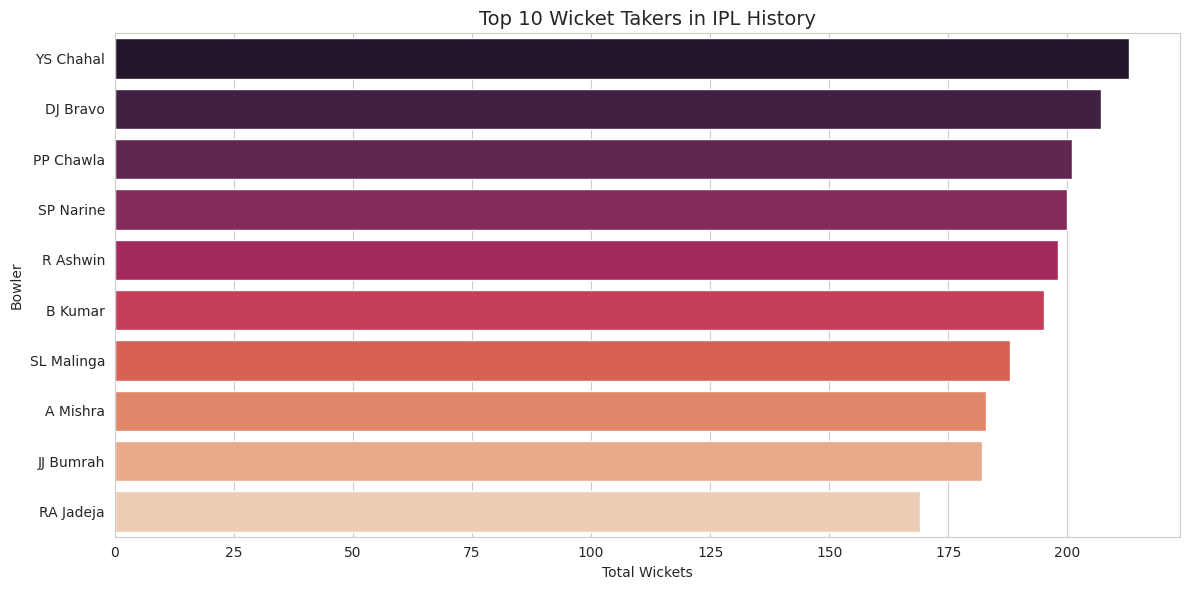

In [22]:

top_bowlers = deliveries[deliveries['is_wicket'] == 1].groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10).reset_index()
top_bowlers.columns = ['bowler', 'wickets']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bowlers, x='wickets', y='bowler', palette='rocket')
plt.title('Top 10 Wicket Takers in IPL History', fontsize=14)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

**Insight:** Yuzvendra Chahal leads all-time wicket takers with 210+ wickets, 
followed closely by DJ Bravo. Interestingly, JJ Bumrah despite being considered 
the best T20 bowler in the world sits at 9th — highlighting that wicket count 
alone doesn't tell the full story. Economy rate and death bowling effectiveness 
matter equally in T20 cricket.

## Season-wise Analysis

How has the IPL evolved over the years? Let's look at match counts, 
run rates and margins across all 16 seasons.

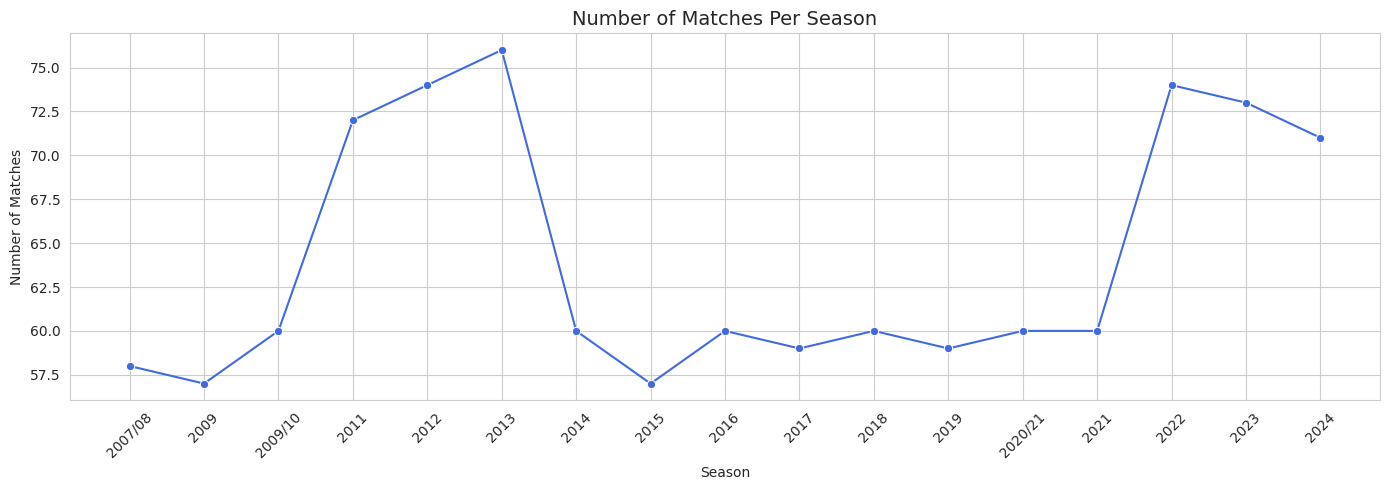

In [23]:

matches_per_season = matches.groupby('season').size().reset_index(name='matches')

plt.figure(figsize=(14, 5))
sns.lineplot(data=matches_per_season, x='season', y='matches', marker='o', color='royalblue')
plt.title('Number of Matches Per Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** IPL 2013 had the highest number of matches (76) following expansion 
to 9 teams. The sharp drop in 2014-2015 reflects the suspension of Chennai Super 
Kings and Rajasthan Royals due to the spot fixing controversy. The recent jump in 
2022 marks the addition of two new franchises — Gujarat Titans and Lucknow Super Giants — 
taking the league back to 74+ matches per season.

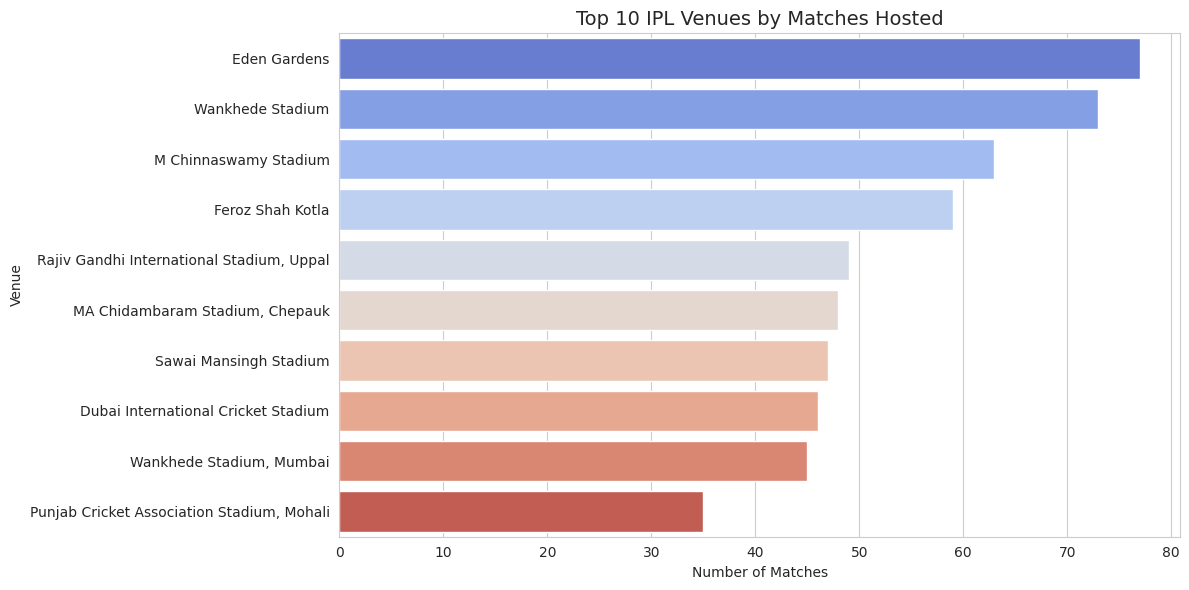

In [24]:

top_venues = matches['venue'].value_counts().head(10).reset_index()
top_venues.columns = ['venue', 'matches']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_venues, x='matches', y='venue', palette='coolwarm')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=14)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

**Insight:** Eden Gardens, Kolkata leads as the most used IPL venue with 76 matches, 
followed by Wankhede Stadium in Mumbai. Interestingly, Wankhede appears twice in the 
dataset under slightly different names — a common data quality issue in real world datasets. 
The presence of Dubai International Cricket Stadium highlights the 2020 season which was 
held entirely in UAE due to COVID-19.

## Key Insights & Conclusion :)

After analyzing 1090 IPL matches and 260,920 deliveries across 16 seasons, 
here are the most important findings:

1. **Mumbai Indians** are the most successful IPL franchise with 145+ wins — 
nearly 10 wins ahead of Chennai Super Kings in second place.

2. **Toss advantage is a myth** — toss winning teams won only ~51% of matches, 
barely above a coin flip. Skill matters far more than the toss.

3. **Virat Kohli** is the greatest IPL batter of all time with 8000+ runs — 
1500 runs clear of the second placed Shikhar Dhawan.

4. **Yuzvendra Chahal** leads all time wicket takers with 210+ wickets, 
proving that wrist spinners are the most effective bowling option in T20 cricket.

5. **IPL 2013** was the biggest season with 76 matches, while the 2014-2015 
dip reflects the spot fixing scandal that led to team suspensions.

6. **Eden Gardens** is the most used venue — a testament to Kolkata's 
passionate cricket culture and stadium capacity.

### Final Thoughts
This analysis only scratches the surface of what IPL data can reveal. 
Future work could include predictive modeling for match outcomes, 
player performance forecasting and deeper venue-specific analysis.